In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dictionary mapping asset names to their corresponding CSV files
files = {
    "BTC": "cleaned_BTC_USD_daily_data.csv",
    "ETH": "cleaned_ETH_USD_daily_data.csv",
    "BNB": "cleaned_BNB_USD_daily_data.csv",
    "SOL": "cleaned_SOL_USD_daily_data.csv",
    "XRP": "cleaned_XRP_USD_daily_data.csv"
}

crypto_data = {}

print("Starting data loading process...")

for asset, file in files.items():
    try:
        # Load the dataset
        df = pd.read_csv(file)
        
        # clean column names by removing whitespace
        df.columns = df.columns.str.strip()
        
        # Convert date column to datetime objects
        if 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
        elif 'Date' in df.columns:
            df['date'] = pd.to_datetime(df['Date'])
        
        # Calculate Daily_Return if it does not exist
        if 'Daily_Return' not in df.columns:
            df['Daily_Return'] = df['Close'].pct_change()
        
        # Standardize the column name to lowercase for consistency
        df['daily_return'] = df['Daily_Return']
        
        # Remove rows with missing values created by the percentage change calculation
        df = df.dropna(subset=['daily_return'])
        
        # Store processed DataFrame in the dictionary
        crypto_data[asset] = df
        print(f"Successfully loaded {asset}")
        
    except Exception as e:
        print(f"Error loading {asset}: {e}")

Starting data loading process...
Successfully loaded BTC
Successfully loaded ETH
Successfully loaded BNB
Successfully loaded SOL
Successfully loaded XRP


In [7]:
def rolling_volatility(df, window=30):
    # Calculates the standard deviation of returns over a moving window
    return df['daily_return'].rolling(window).std()

def max_drawdown(df):
    # Calculates the maximum observed loss from a historical peak
    cumulative_returns = (1 + df['daily_return']).cumprod()
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

def downside_volatility(df):
    # Calculates standard deviation using only negative returns to measure downside risk
    negative_returns = df[df['daily_return'] < 0]['daily_return']
    return negative_returns.std()

def calculate_var(df, confidence_level=0.05):
    # Calculates Value at Risk at 95% confidence (5th percentile of returns)
    return df['daily_return'].quantile(confidence_level)

In [8]:
risk_metrics = []

for asset, df in crypto_data.items():
    # Calculate 30-day rolling volatility for plotting later
    df['vol_30'] = rolling_volatility(df, window=30)
    
    # Calculate scalar metrics for the summary table
    # Annualized volatility: Daily Std Dev * Square Root of 365
    vol_ann = df['daily_return'].std() * np.sqrt(365)
    
    # Maximum Drawdown (Task 2)
    dd = max_drawdown(df)
    
    # Downside Volatility (Task 2)
    down_vol = downside_volatility(df)
    
    # Value at Risk (Task 3)
    var_95 = calculate_var(df)
    
    # Append results to the list
    risk_metrics.append({
        'Asset': asset,
        'Volatility_Ann': vol_ann,
        'Max_Drawdown': dd,
        'Downside_Vol': down_vol,
        'VaR_95': var_95
    })

# Create a DataFrame to display the calculated metrics
display_table = pd.DataFrame(risk_metrics)

print("Calculated Risk Metrics: ")
display(display_table)

Calculated Risk Metrics: 


,Asset,Volatility_Ann,Max_Drawdown,Downside_Vol,VaR_95
0,BTC,0.696790,-0.833990,0.027652,-0.056745
1,ETH,0.882469,-0.939625,0.033908,-0.069649
2,BNB,1.033726,-0.801024,0.035362,-0.070133
3,SOL,1.316527,-0.962725,0.042397,-0.089582
4,XRP,1.182801,-0.958661,0.037272,-0.073582


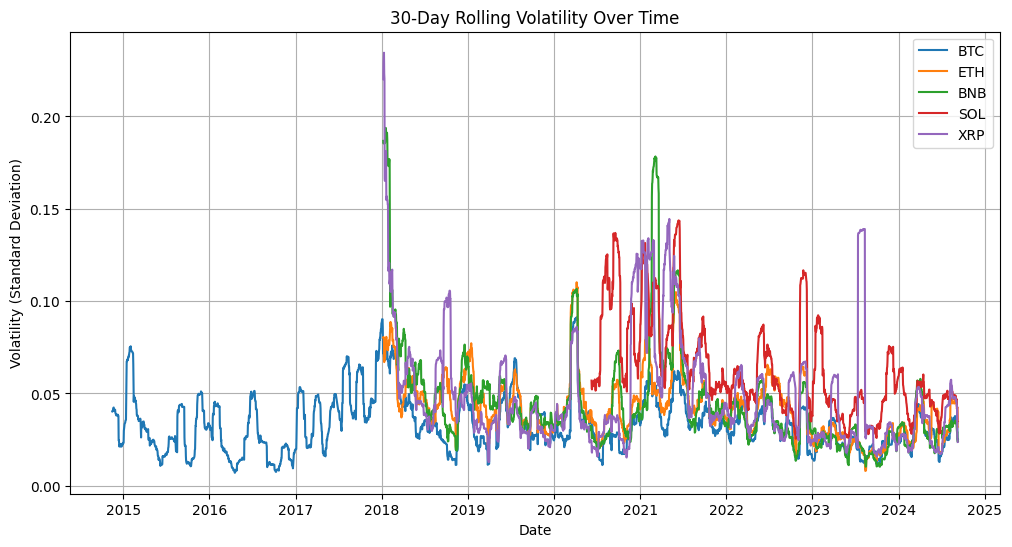

In [9]:
# Plotting 30-Day Rolling Volatility for all assets
plt.figure(figsize=(12, 6))

for asset, df in crypto_data.items():
    plt.plot(df['date'], df['vol_30'], label=asset)

plt.title('30-Day Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation)')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Create a copy of the metrics table for scoring
risk_df = display_table.copy()

def normalize(series, higher_is_riskier):
    # Normalizes data to a 0-1 scale
    min_val = series.min()
    max_val = series.max()
    
    # Handle edge case where all values are identical
    if min_val == max_val:
        return 0.5 

    if higher_is_riskier:
        # Formula for metrics where higher values mean higher risk (e.g., Volatility)
        return (series - min_val) / (max_val - min_val)
    else:
        # Formula for metrics where lower/negative values mean higher risk (e.g., Drawdown)
        return (series - max_val) / (min_val - max_val)

# Normalize the core metrics
risk_df['Norm_Vol'] = normalize(risk_df['Volatility_Ann'], higher_is_riskier=True)
risk_df['Norm_DD'] = normalize(risk_df['Max_Drawdown'], higher_is_riskier=False)
risk_df['Norm_VaR'] = normalize(risk_df['VaR_95'], higher_is_riskier=False)

# Calculate Risk Score (0 to 100)
# Weights: Volatility (30%), Drawdown (40%), VaR (30%)
risk_df['Risk_Score'] = (
    (risk_df['Norm_Vol'] * 0.30) +
    (risk_df['Norm_DD'] * 0.40) +
    (risk_df['Norm_VaR'] * 0.30)
) * 100

def get_risk_category(score):
    # Assigns a label based on the numerical score
    if score < 33:
        return 'Low Risk'
    elif score < 66:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_df['Risk_Category'] = risk_df['Risk_Score'].apply(get_risk_category)

# Prepare the final report
final_columns = ['Asset', 'Risk_Score', 'Risk_Category', 'Volatility_Ann', 'Max_Drawdown', 'VaR_95', 'Downside_Vol']
final_report = risk_df[final_columns].sort_values(by='Risk_Score', ascending=False).reset_index(drop=True)

print("Final Risk Analysis (Task 4):")
display(final_report)

# Save the file for Task 5 (Backend Integration)
final_report.to_csv("crypto_risk_scored.csv", index=False)
print("File 'crypto_risk_scored.csv' has been saved.")

Final Risk Analysis (Task 4):


,Asset,Risk_Score,Risk_Category,Volatility_Ann,Max_Drawdown,VaR_95,Downside_Vol
0,SOL,100.000000,High Risk,1.316527,-0.962725,-0.089582,0.042397
1,XRP,77.903979,High Risk,1.182801,-0.958661,-0.073582,0.037272
2,ETH,55.062884,Medium Risk,0.882469,-0.939625,-0.069649,0.033908
3,BNB,28.541674,Low Risk,1.033726,-0.801024,-0.070133,0.035362
4,BTC,8.154791,Low Risk,0.696790,-0.833990,-0.056745,0.027652


File 'crypto_risk_scored.csv' has been saved.
